### Brief Introduction
* High energy cosmic rays (hardons) and $\gamma$-rays interact with the Earth's atmosphere resulting in a phenomenon called Cherenkov radiation. Successive interaction of the particles with the atmosphere create pools of light called Extensive Air Showers (EAS).
* Imaging these showers is the primary method of detection of these high energy particles. The morphology of these showers encode information about the particle like its type, energy, direction which are derived through a principal component analysis called Hillas parametrization. 
* The result of this parametrization for MC simulated shower events are given in this dataset
We are interested in the $\gamma$-ray induced showers over the background hadronic showers. 
* We can exploit the morphologicl differences between the gamma and hadron EAS using a classifier to separate the signal from the dominant background 

### Dataset Description
1.  fLength:  continuous  -  major axis of ellipse [mm]
2.  fWidth:   continuous  - minor axis of ellipse [mm] 
3.  fSize:    continuous  - 10-log of sum of content of all pixels [in #phot]
4.  fConc:    continuous  - ratio of sum of two highest pixels over fSize  [ratio]
5.  fConc1:   continuous  - ratio of highest pixel over fSize  [ratio]
6.  fAsym:    continuous  - distance from highest pixel to center, projected onto major axis [mm]
7.  fM3Long:  continuous  - 3rd root of third moment along major axis  [mm] 
8.  fM3Trans: continuous  - 3rd root of third moment along minor axis  [mm]
9.  fAlpha:   continuous  - angle of major axis with vector to origin [deg]
10.  fDist:    continuous  - distance from origin to center of ellipse [mm]
11.  class:    g,h  - gamma (signal), hadron (background)


Imports

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from imblearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

/home/shahjahan/anaconda3/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [3]:
df = pd.read_csv('../DATASETS/magic04_gamma.csv')
df.head()
# Drop the ID Column
df = df.drop('Unnamed: 0', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [5]:
print("Dataset Description")
print(f"Rows: {len(df)}")
print(f"Missing Values : {df.isnull().sum().sum()}")

print("Class Distrubution")
val = df['class'].value_counts()

print(f"Gamma: {val['g']/sum(val) * 100:.2f}%")
print(f"Hadron: {val['h']/sum(val) * 100:.2f}%")
print(f"Gamma - Hadron ratio = {val['g'] / val['h']}")
print("There is a class imbalance which could introduce a bias in the model. We'll use a random over-sampler to balance this")

Dataset Description
Rows: 19020
Missing Values : 0
Class Distrubution
Gamma: 64.84%
Hadron: 35.16%
Gamma - Hadron ratio = 1.8438995215311005
There is a class imbalance which could introduce a bias in the model. We'll use a random over-sampler to balance this


Visualizing the dataset

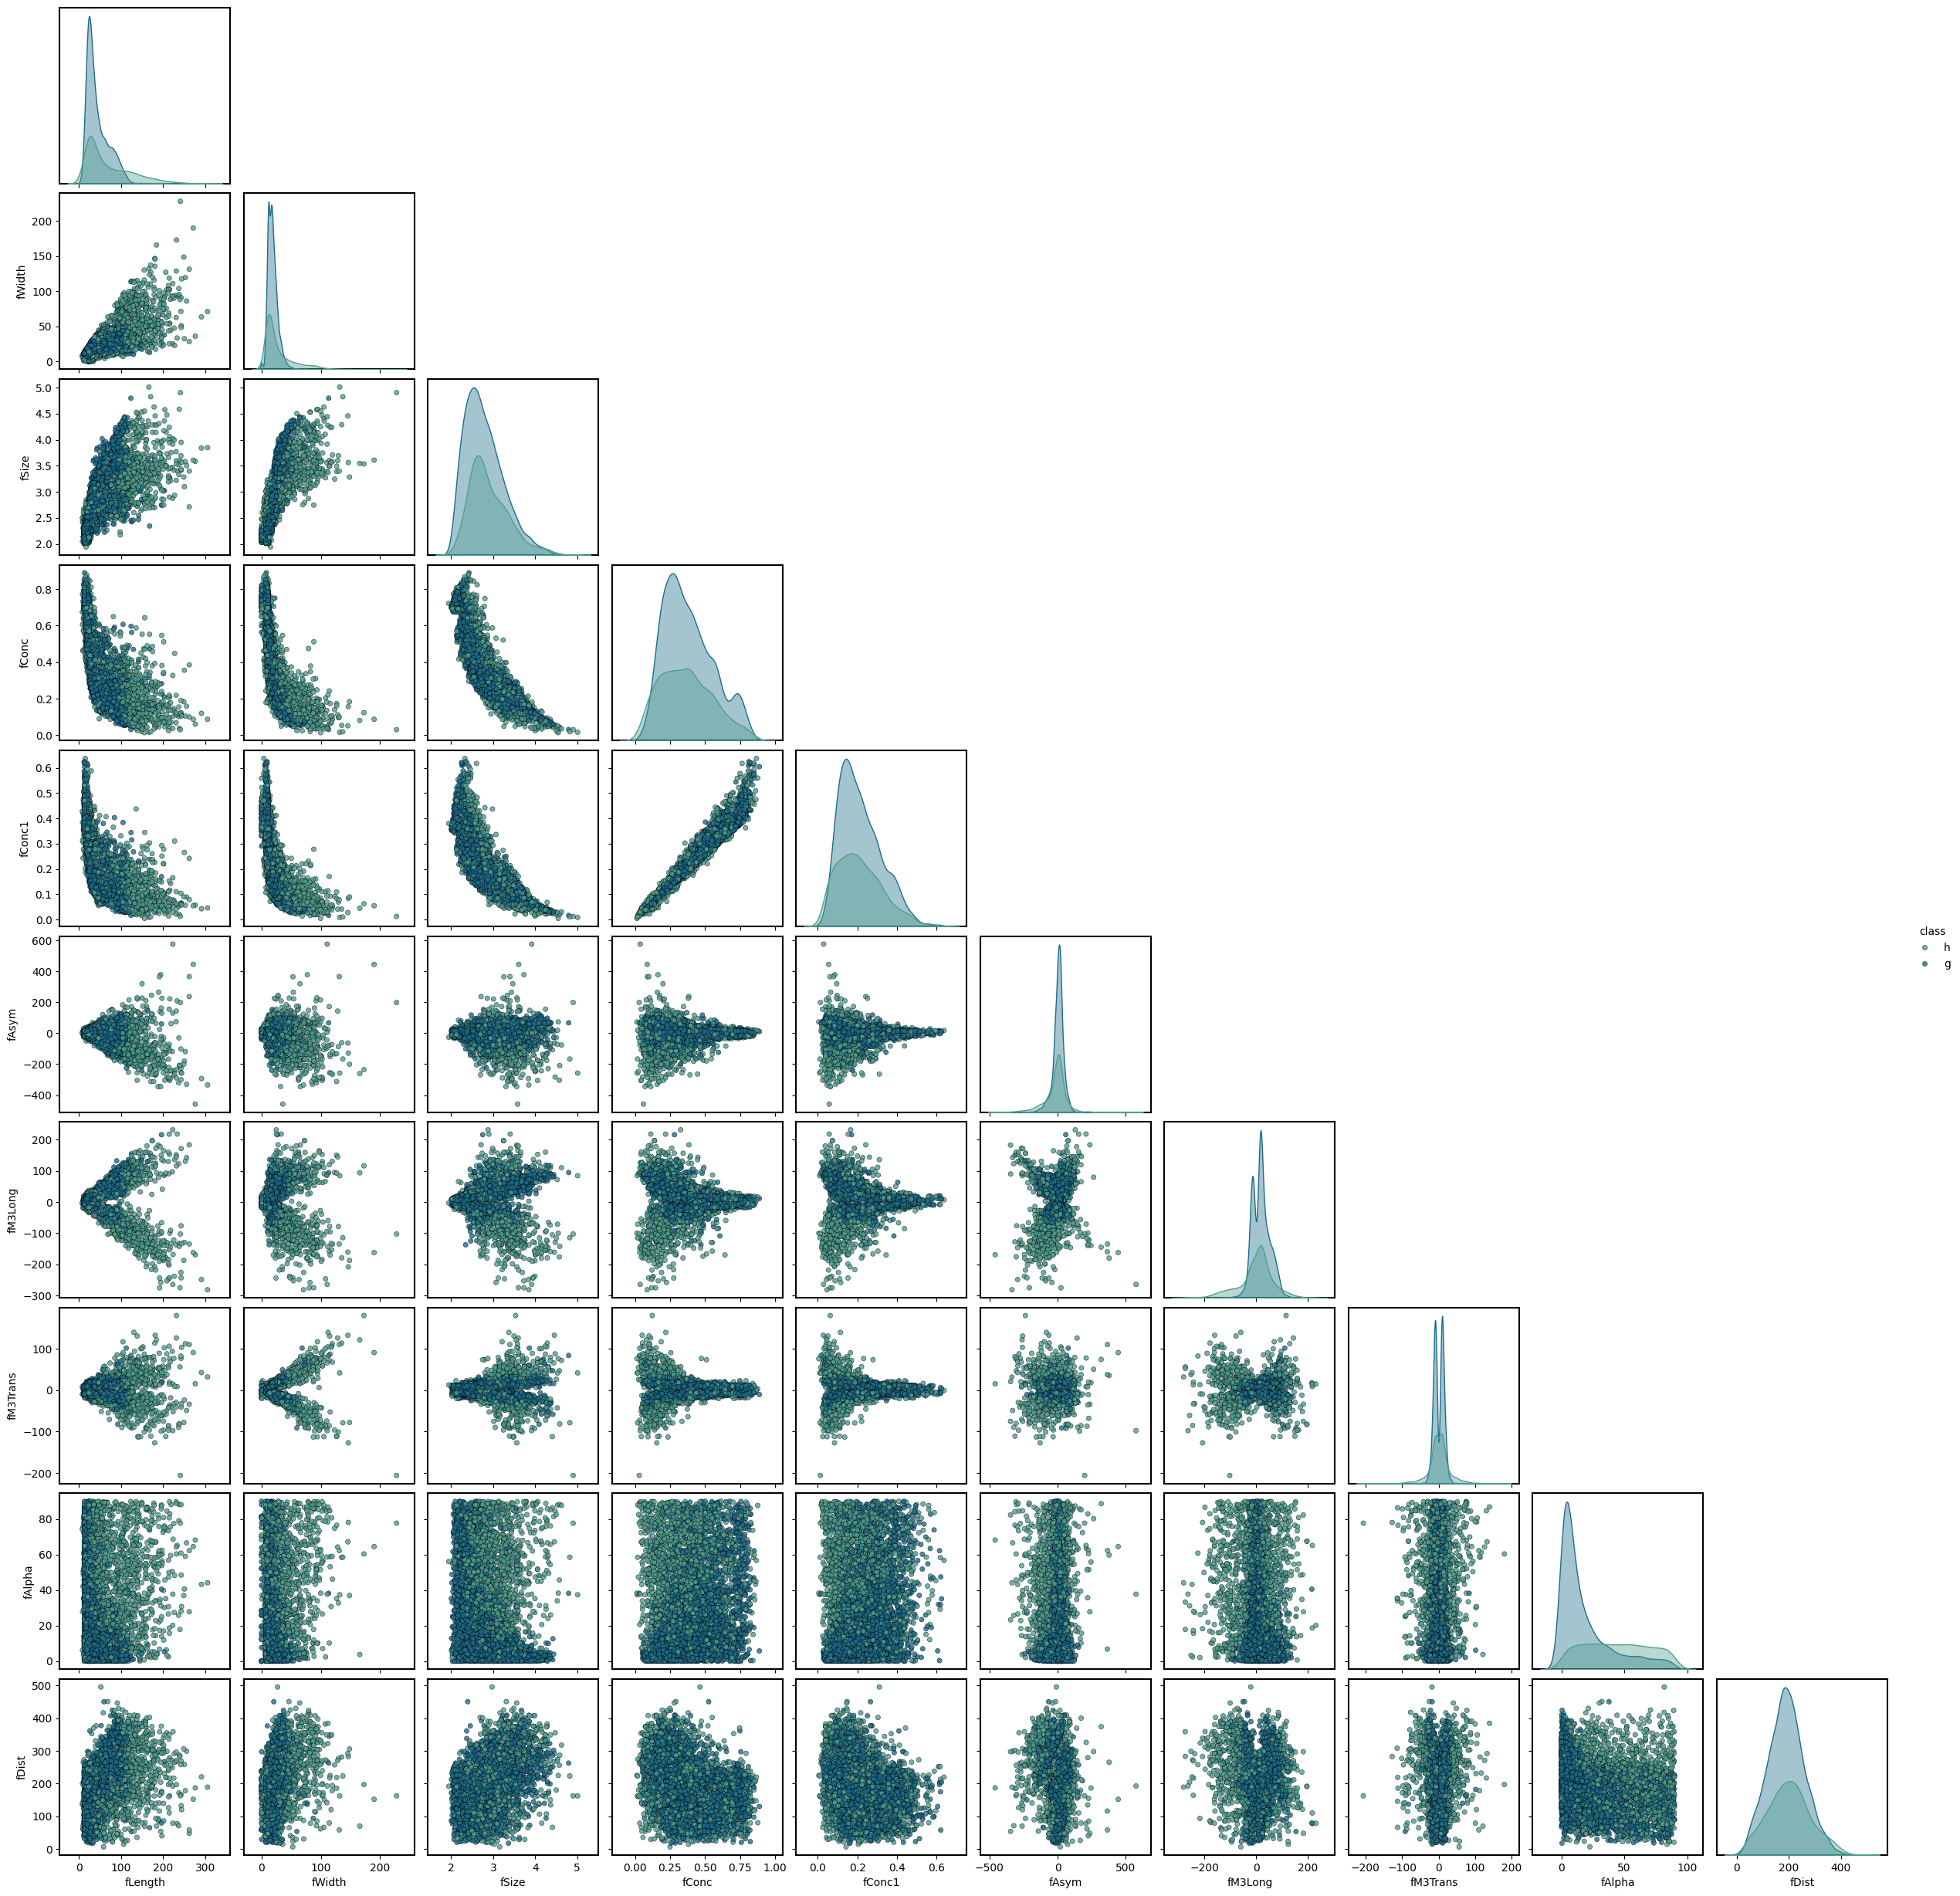

In [6]:
# Pair Plotting a smaller subset of the data for easy visualization
df_compact = df.sample(n=6000, random_state=0,)   

palette = sns.color_palette("crest", 2)

g = sns.pairplot(df_compact, hue='class', palette=palette,
             plot_kws={'alpha': 0.8, 's': 20,'edgecolor': 'black'},
             diag_kws={'alpha': 0.4},
             corner = True,
             )
for ax in g.axes.flatten():
    if ax is not None:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor("black")

plt.show()

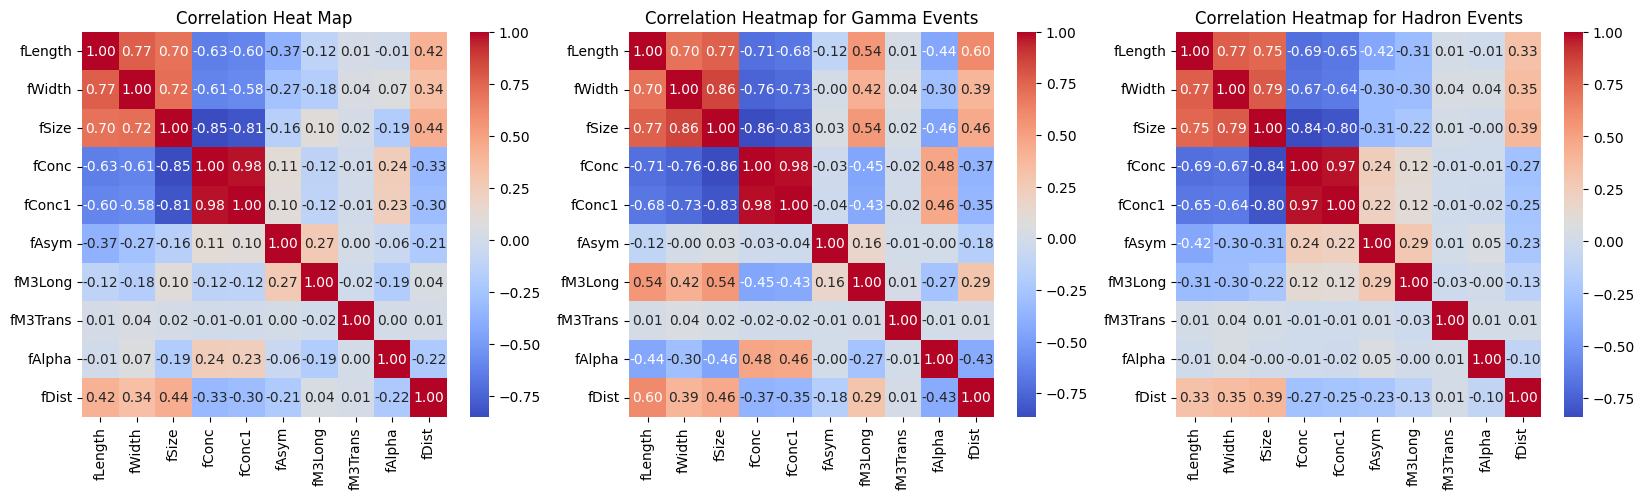

In [29]:
numerical_features = df.select_dtypes(include='number')
corr_mat = numerical_features.corr()
fig, ax = plt.subplots(1,3, figsize=(20, 5))


g_num_ft = df[df['class'] == 'g'].select_dtypes(include='number')
g_cmat = g_num_ft.corr()
h_num_ft = df[df['class'] == 'h'].select_dtypes(include='number')
h_cmat = h_num_ft.corr()



titles = ["Correlation Heat Map", "Correlation Heatmap for Gamma Events", "Correlation Heatmap for Hadron Events"]
corrs = [corr_mat, g_cmat, h_cmat]
for i in range(len(corrs)):
   
    sns.heatmap(corrs[i], annot = True, fmt =".2f", cmap='coolwarm', ax = ax[i])
    ax[i].set_title(titles[i])
plt.show()


### Interpreting the Pairplots and Correlations
<figure>
  <img src="https://user-images.githubusercontent.com/17825673/58326449-2885db80-7e2d-11e9-8d57-a2175840f161.png" alt="Hillas Parameters Diagram" style="width:30%">
  <figcaption align="left">
    Fig.1: Diagram explaining the different Hillas parameters.
  </figcaption>
</figure>
* fLength, fWidth and fSize show strong positive correlation as expected from EAS development. Larger showers tend to be longer, wider and generally tend to increase the overall intensity (although the relation between the geometric size and intensity is not that simple). 
* The strong negative correlation of fLength, fWidth, fSize with fConc and fConc1 is also expected. Larger showers comparatively spread their intensities rather than concentrating them at the central pixels 
* fM3Long and fM3Trans seem to be good discriminators indicated by their opposing correlations with the size parameters for the two classes
* fConc and fConc1 are highly correlated which is understandable based on the way they are computed. While multi-collinearity is not a cause of concern in the implementation of a Random Forest Classifier. We can drop one of these features 
* fAlpha looks like a strong discriminator between $\gamma$ and hadron. But this feature will strongly bias our classifier. The alpha is defined as the difference between the angle the semi-major axis of the Hillas ellipse makes with the detector horizontal and the line joining the centroid of the ellipse to the source position (Refer Fig.1). This means that at smaller alphas, one would expect to find more $\gamma$-ray showers over background, artificially inflating the model performance by exploiting observational geometry rather than physical differences in the shower structure. We would like to discriminate between events based purely on the morphological features of the showers and not their geometric alignment with the source position, therefore, this feature will be dropped to ensure the clasifier learns morphology-driven separation

In [ ]:
# Dropping fConc1 and fAlpha
df = df.drop(['fConc1', 'fAlpha'], axis = 1)

### Train-Test Split
We will:
1. Separate features and target variable
2. Encode the target labels (g = 0, h = 1)
3. Create a train-test split with 25% of the data being used for testing 
4. Create a classifier pipeline consisting of a random oversampler and a random forest classifier

In [32]:
# Separate features and target variable

X = df.drop('class', axis=1)
y = df['class']

# Encode the target labels

enc = LabelEncoder()
enc.fit(df['class'])
y = enc.transform(df['class'])

for i, label in enumerate(enc.classes_):
    print(f"{label}: {i}")

# Since we are using a RadomForest, scaling is not strictly necessary.

# Create a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1,stratify=y)

# Pipeline with RandomOverSampler and RandomForestClassifier

# As there is a class imbalance, perform random oversampling for the minority class to prevent bias 
pipeline = Pipeline([
    ('ros', RandomOverSampler(random_state=0)),
    ('rf', RandomForestClassifier(class_weight='balanced'))
])

g: 0
h: 1


In [33]:
pipeline

Pipeline(steps=[('ros', RandomOverSampler(random_state=0)),
                ('rf', RandomForestClassifier(class_weight='balanced'))])

* We will tune the hyperparameters of our RF classifier using RandomizedSearchCV with a 5-fold cross validation. RandomizedSearchCV is preferred due to its efficiency in exploring the parameter space with fewer evaluations. 
* The optimization is done using the F1-score which balances precision and recall. This is important in our case as both false positives (hadron leakage) and false negatives (loss of gamma events) are critical

In [ ]:
# Use RandomizedSearchCV for hyperparameter tuning over GridSearchCV for faster convergence

param_grid = {
    'rf__n_estimators': [100, 200, 300,],
    "rf__max_depth": [3, 4, 5, 6, 7, None],
    "rf__min_samples_split": [2, 4, 6],
    "rf__min_samples_leaf": [2, 3, 4, 5, 6, 7],
    "rf__max_features": ["sqrt", "log2"]
}

grid = RandomizedSearchCV(
    estimator = pipeline,
    param_distributions = param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose = True,
    n_iter=30,
)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/shahjahan/anaconda3/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/home/shahjahan/anaconda3/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/t

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('ros',
                                              RandomOverSampler(random_state=0)),
                                             ('rf',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'rf__max_depth': [3, 4, 5, 6, 7, None],
                                        'rf__max_features': ['sqrt', 'log2'],
                                        'rf__min_samples_leaf': [2, 3, 4, 5, 6,
                                                                 7],
                                        'rf__min_samples_split': [2, 4, 6],
                                        'rf__n_estimators': [100, 200, 300]},
                   scoring='f1', verbose=True)

In [37]:
print("Best parameters:", grid.best_params_)
print("Best cross-val score:", grid.best_score_)

Best parameters: {'rf__n_estimators': 100, 'rf__min_samples_split': 4, 'rf__min_samples_leaf': 3, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
Best cross-val score: 0.7378715362998085


In [38]:
import pickle
filename = 'random_forest_model_MAGIC.pkl'
with open(filename, 'wb') as file:
    pickle.dump(grid.best_params_, file)

In [39]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('ros', RandomOverSampler(random_state=0)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=3,
                                        min_samples_split=4))])

Once the test data is fed into the RF, one can compute a "gammaness" parameter which is the probability that a particular event is a gamma ray shower event. 

In [40]:
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)[:, 1]

Accuracy: 83.43%       	Recall: 90.24%      	Precision: 85.10%      	F1 Score: 87.59%


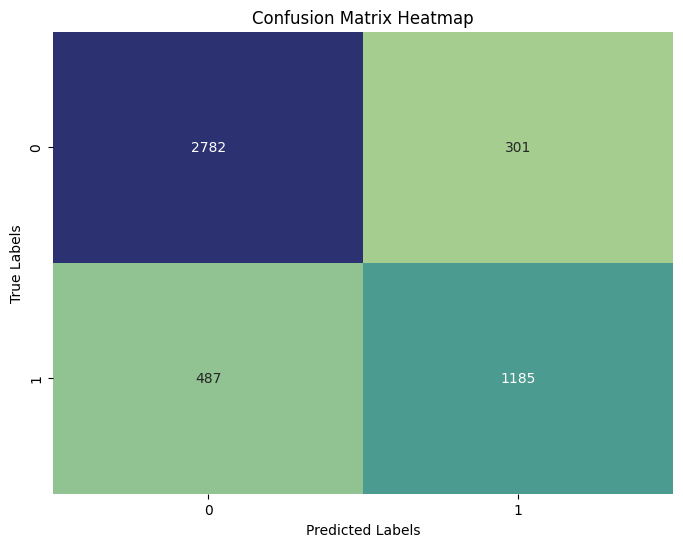

In [62]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label=0)
precision = precision_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print(f'Accuracy: {accuracy * 100:.2f}% \
      \tRecall: {recall * 100:.2f}%\
      \tPrecision: {precision * 100:.2f}%\
      \tF1 Score: {f1 * 100:.2f}%'
      )

conf_matrix = confusion_matrix(y_test, y_pred)
ticks = sklearn.utils.multiclass.unique_labels(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='crest', cbar=False, 
            xticklabels=ticks, yticklabels= ticks)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

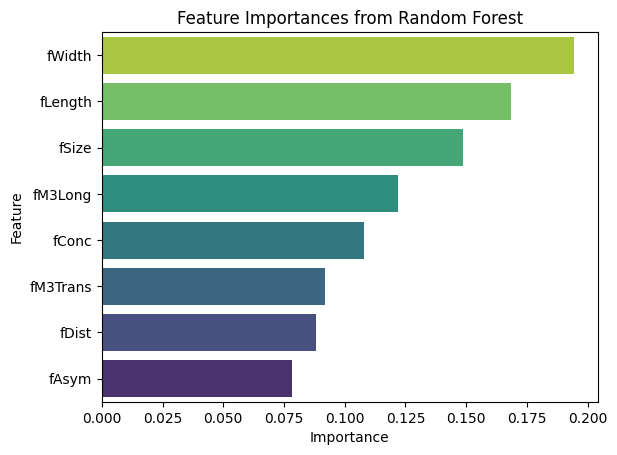

In [ ]:
feature_importances = best_model.named_steps['rf'].feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis_r', hue = 'Feature', legend = False)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [60]:
ind = np.argwhere(y_pred == 0) #Indices where predicted class is gamma
actual_gamma = np.argwhere((y_pred == 0) & (y_test == 0)) #Indices where predicted class is gamma and true class is also gamma  
true_gamma_count = np.sum(y_test == 0)
actual_hadron = np.argwhere((y_pred == 1) & (y_test == 1)) #Indices where predicted class is hadron and true class is also hadron
true_hadron_count = np.sum(y_test == 1)
false_gamma = np.argwhere((y_pred == 1) & (y_test == 0)) #Indices where predicted class is hadron but true class is gamma
print(f"Total predicted gamma events: {len(ind)}")
print(f"Total true gamma events correctly predicted: {len(actual_gamma)} out of {true_gamma_count}")
print(f"Total true hadron events correctly predicted: {len(actual_hadron)} out of {true_hadron_count}")
print(f"Total gamma events misclassified as hadrons: {len(false_gamma)} out of {np.sum(y_test == 0)}\n")


epsilon_gamma = np.round(np.sum((y_pred == 0) & (y_test == 0)) / true_gamma_count, 2)
hadron_leakage = np.round(np.sum((y_pred == 0) & (y_test == 1)) / true_hadron_count, 2)
epsilon_hadron = np.round(np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_test == 1), 2)
Q = np.round(epsilon_gamma / np.sqrt(hadron_leakage), 2)
eff_str = "Efficiencies (Predicted Count / True Count for each class)"
print("-" * len(eff_str))
print(eff_str)
print("-" * len(eff_str))
print(f"e_gamma: {epsilon_gamma*100}%")
print(f"e_hadron: {epsilon_hadron*100}%\n")
print(f"Hadron leakage: {hadron_leakage *100:.1f}%")

print(f"Q factor: {Q}")  

Total predicted gamma events: 3269
Total true gamma events correctly predicted: 2782 out of 3083
Total true hadron events correctly predicted: 1185 out of 1672
Total gamma events misclassified as hadrons: 301 out of 3083

----------------------------------------------------------
Efficiencies (Predicted Count / True Count for each class)
----------------------------------------------------------
e_gamma: 90.0%
e_hadron: 71.0%

Hadron leakage: 29.0%
Q factor: 1.67


### Plot of "Gamaness" distribution and optimizing threshold with Q-Factor
* We separate the test dataset into gammas and hadrons and plot the hadronnness (or gammaness) score assigned by the model. This makes a great visualization of the performance of our model.
* To evaluate the results of the classifier in a physically meaningful way, we compute the **Q-factor**, defined as:
$$\frac{\text{True Gamma}}{\sqrt{\text{Hadron Leakage}}}$$
* This metric is widely used in gamma-ray astronomy for optimizing event-selection cuts.
* The Q-factor will help explore the trade-off between retaining signal events and suppressing background events. We can determine where to impose a cut on the probability score to maximize the gamma-ray events within that threshold . 
* From the results, we can see that a tighter cut (large threshold value) will significantly reduce hadron leakage but also diminish the gamma-ray efficiency. 
* This is reflected in the Q-factor calculation at every threshold cut as seen in the plot below. Beyond a threshold of $\sim 0.7$ the Q-factor begins to drop. The optimal cut is therefore not trivial and must balance both effects.
* We will constrain e_gamma>90% to ensure that signal loss is within an acceptable range and optimize the threshold, maximizing the Q-factor  

Q(e_gamma>0.9) 1.67 at threshold 0.50,       
e_gamma: 90.24%, hadron leakage: 29.13%


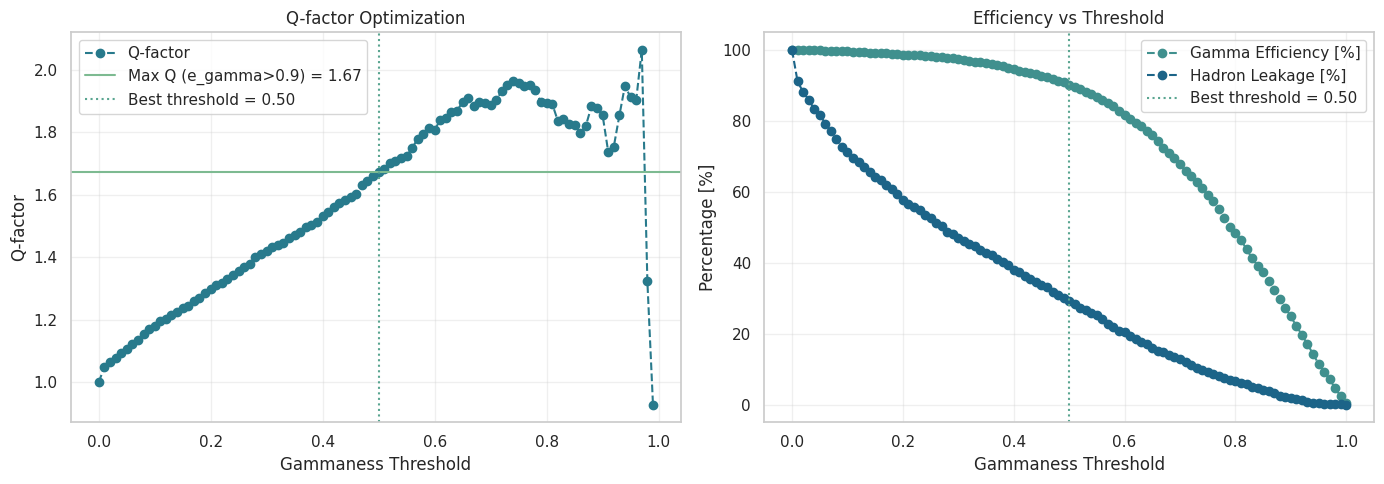

In [74]:
def Q_factor(e_gamma, h_leakage):
    e = np.array(e_gamma, dtype=float)
    h = np.array(h_leakage, dtype=float)

    h[h == 0] = np.nan
    Q = e / np.sqrt(h)
    return Q

gamma_mask = y_test == 0
hadron_mask = y_test == 1 

gamma_probs = best_model.predict_proba(X_test[gamma_mask])[:, 0]
hadron_probs = best_model.predict_proba(X_test[hadron_mask])[:, 0]

gamma_eff = []
hadron_leak = []

thresholds = np.linspace(0, 1, 101)

for thresh in thresholds:
    g_eff = np.sum(gamma_probs >= thresh) / len(gamma_probs)   
    h_l   = np.sum(hadron_probs >= thresh) / len(hadron_probs) 

    gamma_eff.append(g_eff)
    hadron_leak.append(h_l)


gamma_eff = np.array(gamma_eff)
hadron_leak = np.array(hadron_leak)

Q = Q_factor(gamma_eff, hadron_leak)


mask = gamma_eff > 0.9
Q_constrained = np.where(mask, Q, np.nan)

best_idx = np.nanargmax(Q_constrained)

print(f"Q(e_gamma>0.9) {Q_constrained[best_idx]:.2f} at threshold {thresholds[best_idx]:.2f},\
       \ne_gamma: {gamma_eff[best_idx]*100:.2f}%, hadron leakage: {hadron_leak[best_idx]*100:.2f}%")


sns.set_theme(style="whitegrid")
palette = sns.color_palette("crest")

best_threshold = thresholds[best_idx]
best_Q = Q_constrained[best_idx]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Q-factor vs threshold

ax = axes[0]

ax.plot(thresholds, Q, marker='o', linestyle='--',
        color=palette[3], label="Q-factor")

# Highlight best Q
ax.axhline(best_Q, color=palette[0], linestyle='-',
           label=f"Max Q (e_gamma>0.9) = {best_Q:.2f}")

ax.axvline(best_threshold, color=palette[1], linestyle=':',
           label=f"Best threshold = {best_threshold:.2f}")

ax.set_title("Q-factor Optimization")
ax.set_xlabel("Gammaness Threshold")
ax.set_ylabel("Q-factor")

ax.legend(frameon=True)
ax.grid(alpha=0.3)


# RIGHT: Efficiency vs threshold

ax = axes[1]

ax.plot(thresholds, gamma_eff * 100,
        marker='o', linestyle='--',
        color=palette[2], label="Gamma Efficiency [%]")

ax.plot(thresholds, hadron_leak * 100,
        marker='o', linestyle='--',
        color=palette[4], label="Hadron Leakage [%]")

# Mark best threshold
ax.axvline(best_threshold, color=palette[1], linestyle=':',
           label=f"Best threshold = {best_threshold:.2f}")

ax.set_title("Efficiency vs Threshold")
ax.set_xlabel("Gammaness Threshold")
ax.set_ylabel("Percentage [%]")

ax.legend(frameon=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A threshold cut at gammaness = 0.5 seems to best optimize the Q factor. Therefore, while choosing gamma ray events, we will only consider the ones whose gammaness score exceeds 0.5.

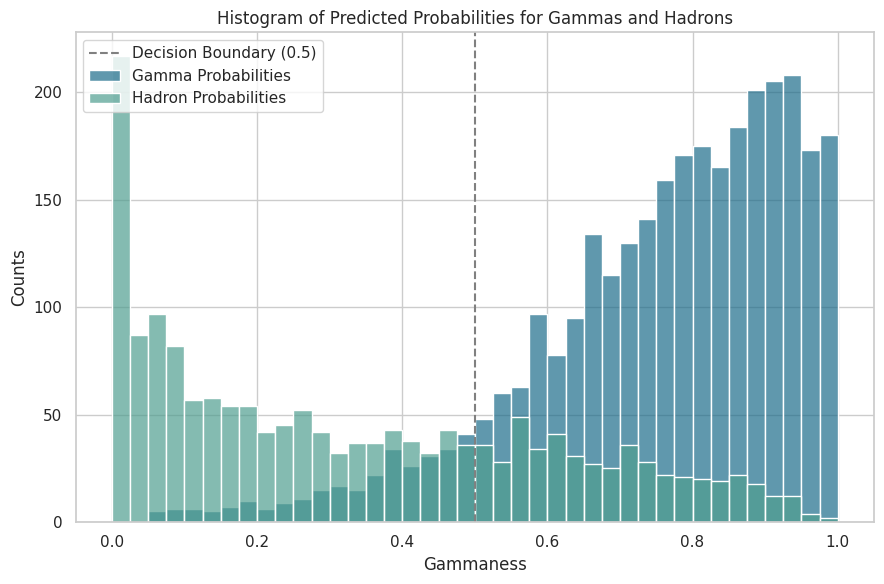

In [75]:
# Take test samples of pure gammas and pure hadrons to calculate probs and plot them
gamma_mask = y_test == 0
hadron_mask = y_test == 1 

gamma_probs = best_model.predict_proba(X_test[gamma_mask])[:,0]
hadron_probs = best_model.predict_proba(X_test[hadron_mask])[:,0]

palette = sns.color_palette("crest", 2)
bins = np.linspace(0, 1, 41) 

plt.figure(figsize=(9, 6))
sns.histplot(gamma_probs, bins=bins, stat='count',
             color=palette[1], alpha=0.7, label='Gamma Probabilities', kde=False)
sns.histplot(hadron_probs, bins=bins, stat='count',
             color=palette[0], alpha=0.7, label='Hadron Probabilities', kde=False)

plt.xlabel('Gammaness')
plt.ylabel('Counts')
plt.axvline(best_threshold, color='grey', linestyle='--', label=f'Decision Boundary ({best_threshold})')
plt.title('Histogram of Predicted Probabilities for Gammas and Hadrons')
plt.legend()
plt.tight_layout()
plt.show()

The separation between gamma and hadron probability distributions is evident but there is also a partial overlap which is indicative of some intrinsic similarity between the two shower morphologies. The threshold at 0.5 separates the bulk of the two distributions but still an overlap of the hadronic events continue to contaminate the signal. 